# 手撕APO

In [1]:
import os
import torch 
import json
import math
import numpy as np
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.nn.utils.rnn import pad_sequence
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader

# 加载tokenizer

In [2]:
model_dir = "LLM-Research/Llama-3___2-1B-Instruct/"
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=True)

# 设置pad token（llama3.2没有pad token）
tokenizer.pad_token = tokenizer.eos_token
tokenizer.pad_token_id = tokenizer.eos_token_id

# 加载模型

In [3]:
device = torch.device("cuda") 

# 策略模型
model = AutoModelForCausalLM.from_pretrained(model_dir)
model = model.to(device)

# 参考模型
ref_model = AutoModelForCausalLM.from_pretrained(model_dir)
ref_model.to(device)
ref_model.eval()
for param in ref_model.parameters():
    param.requires_grad = False

# 加载训练数据

In [4]:
dataset = load_dataset("parquet", data_files={
    'train': 'raw_data/data/train-00000-of-00001.parquet'})["train"]
print(f"Train size: {len(dataset)}")

Train size: 5125


# 定义dataset类

In [5]:
class PreferenceDataset(Dataset):
    """输出 (prompt, chosen_text, rejected_text)"""
    def __init__(self, hf_dataset):
        self.data = hf_dataset
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]
        return item["prompt"], item["chosen"], item["rejected"]

# 定义collate_fn

In [6]:
def collate_fn(batch):
    input_ids, labels_list = [], []
    for prompt, chosen_resp, rejected_resp in batch:
        # tokenize prompt和 answer
        prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
        chosen_ids = tokenizer(chosen_resp, add_special_tokens=False)["input_ids"]
        rejected_ids = tokenizer(rejected_resp, add_special_tokens=False)["input_ids"]
        
        # 把一条数据变2条，分别是choose和reject, [[prompt_ids, choose_id], [prompt_ids, rejected_ids]]
        input_ids += [
            torch.tensor(prompt_ids + chosen_ids, dtype = torch.long),
            torch.tensor(prompt_ids + rejected_ids, dtype = torch.long)
        ]
        # mask input token ids
        labels_list += [
            torch.tensor([-100]*len(prompt_ids) + chosen_ids, dtype = torch.long),
            torch.tensor([-100]*len(prompt_ids) + rejected_ids, dtype = torch.long)
        ]

    # batch做padding
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = (input_ids != tokenizer.pad_token_id)
    labels_tensor = pad_sequence(labels_list, batch_first=True, padding_value=-100) # -100代表忽略loss计算
    
    return input_ids.to(device), attention_mask.to(device), labels_tensor.to(device)

# 超参数

In [7]:
batch_size = 4  # batch size
max_lr = 2e-6   # 学习率
min_lr = 1e-7   # 最小学习率
max_norm = 1.0  # 最大梯度范数
num_epochs = 1  # 训练epoch数
beta = 0.1      # APO loss的beta系数
grad_acc_steps = 4  #梯度累积的步数

# 生成Dataloader

In [8]:
train_dataset = PreferenceDataset(dataset)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
)
max_steps = len(train_loader)
print(f"Total steps for one epoch: {max_steps}")

Total steps for one epoch: 1282


# 定义Optimizer

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr)
optimizer.zero_grad()

# 学习率warmup和衰减

In [10]:
def get_lr(cur_step, max_steps, warmup_steps = None):
    warmup_steps = int(0.01*max_steps)
    # warmup
    if cur_step < warmup_steps:
        return max_lr * (cur_step+1) / warmup_steps
    # 超过max steps以最小学习率
    if cur_step > max_steps:
        return min_lr
    # 学习率线性decay
    ratio = (cur_step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * ratio))
    return min_lr + coeff * (max_lr - min_lr)

### APO损失函数
$$
\begin{aligned}
 & \mathcal{L}_{zero}^{APO}(x,y_{w},y_{l};\theta)=-\sigma{\left(r_\theta(x,y_w)\right)}+\sigma{\left(r_\theta(x,y_l)\right)} \\
 & \mathcal{L}_{down}^{APO}(x,y_w,y_l;\theta)=\sigma{\left(r_\theta(x,y_w)\right)}-\sigma{\left(r_\theta(x,y_w)-r_\theta(x,y_l)\right)}
\end{aligned}
$$

In [11]:
# APO 损失
def apo_loss(nll_chosen, nll_rejected, ref_chosen, ref_rejected, beta, loss_type="zero"):
    # nll_chosen, shape=[batch_size,]
    chosen_logratios = ref_chosen - nll_chosen  # nll是-log(p)， r = beta * p(y_w)/p(y_ref_w)
    rejected_logratios = ref_rejected - nll_rejected
    if loss_type == "zero":
        # 增大chosen的似然， 降低rejected似然
        loss_chosen = 1 - F.sigmoid(beta * chosen_logratios)
        loss_rejected = F.sigmoid(beta * rejected_logratios)
    elif loss_type == "down":
        # 降低chosen似然，rejected似然降低更多
        loss_chosen = F.sigmoid(beta * chosen_logratios)
        loss_rejected = 1 - F.sigmoid(chosen_logratios - rejected_logratios)
    loss = loss_chosen + loss_rejected
    
    return loss.mean()

# 开始训练

In [12]:
total_losses = []
for epoch in range(num_epochs):
    model.train()
    for step, (input_ids, attention_mask, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}")):

        # 设置模型梯度累积
        is_grad_accum_step = (step + 1) % grad_acc_steps == 0
        model.require_backward_grad_sync = is_grad_accum_step

        # 策略模型的logits, 用BF16精度训练
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            outputs = model(input_ids, attention_mask=attention_mask)
        logits  = outputs.logits  # [2*batch_size, seq_len, vocab_size]
        
        # 参考模型的logits
        with torch.no_grad():
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                ref_outputs = ref_model(input_ids, attention_mask=attention_mask)
            ref_logits  = ref_outputs.logits # [2*batch_size, seq_len, vocab_size]

        # label左移一位
        logits = logits[...,:-1,:].contiguous() # [2*batch_size, seq_len-1, vocab_size]
        ref_logits = ref_logits[...,:-1,:].contiguous() # [2*batch_size, seq_len-1, vocab_size]
        labels = labels[...,1:].contiguous() # [2*batch_size, seq_len-1]

        # 计算损失
        vocab_size = logits.size(-1)
        bsz = logits.size(0)
        policy_loss  = F.cross_entropy(
            logits.view(-1, vocab_size), labels.view(-1), reduction="none").view(bsz, -1)
        ref_loss= F.cross_entropy(
            ref_logits.view(-1, vocab_size), labels.view(-1), reduction="none").view(bsz, -1)
        # loss求和
        policy_nll = policy_loss.sum(dim=1) # [batch_size]
        ref_nll = ref_loss.sum(dim=1) # [batch_size]

        # 把choose和reject的loss切分出来，[[prompt_ids, choose_id], [prompt_ids, rejected_ids]]
        nll_chosen = policy_nll[0::2]   # [batch_size]
        nll_rejected = policy_nll[1::2] # [batch_size]
        ref_chosen = ref_nll[0::2]
        ref_rejected = ref_nll[1::2]

        # 带入公式，计算 APO loss
        loss = apo_loss(nll_chosen, nll_rejected, ref_chosen, ref_rejected, beta, loss_type="zero")
        loss_value = loss.detach().item()
        total_losses.append(loss_value)
        
        # 打印日志
        if (step + 1) % 100 == 0:
            print(f'apo loss at step {max_steps * epoch + step + 1} is: {loss_value:.4f}')

        # 反向传播梯度累积（这里不立即更新参数）
        loss = loss / grad_acc_steps # 这里要除一个累积的steps
        loss.backward()

        if is_grad_accum_step:
            # 梯度裁剪
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
            # 调整学习率
            lr = get_lr(step, max_steps)
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr
            # 参数更新
            optimizer.step()
            optimizer.zero_grad()

Epoch 1:   8%|▊         | 100/1282 [00:18<03:39,  5.39it/s]

apo loss at step 100 is: 1.0078


Epoch 1:  16%|█▌        | 200/1282 [00:36<03:19,  5.43it/s]

apo loss at step 200 is: 1.0000


Epoch 1:  23%|██▎       | 300/1282 [00:54<02:50,  5.76it/s]

...

Epoch 1:  86%|████████▌ | 1100/1282 [03:21<00:36,  5.04it/s]

apo loss at step 1100 is: 0.6094


Epoch 1:  94%|█████████▎| 1200/1282 [03:39<00:13,  6.27it/s]

apo loss at step 1200 is: 0.5859


Epoch 1: 100%|██████████| 1282/1282 [03:55<00:00,  5.44it/s]


# 画图

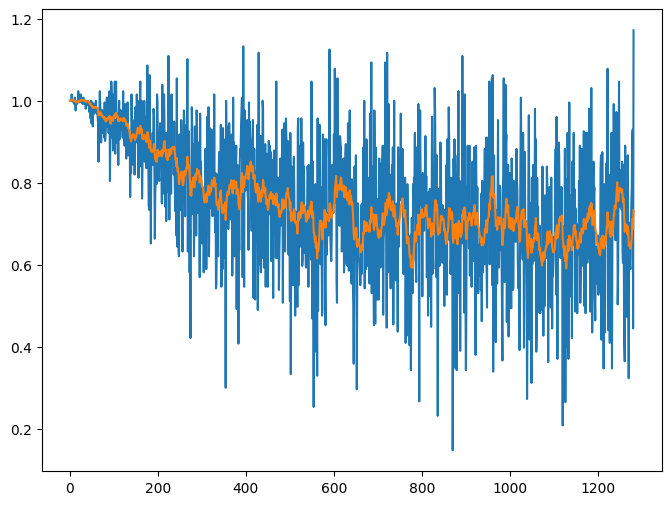

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

fig = plt.figure(figsize=(8, 6))
iters = range(len(total_losses))
pd.Series(total_losses, iters).plot(label='loss') # 原始曲线
pd.Series(total_losses, iters).ewm(span=20).mean().plot(label='smothed loss') # 平滑后曲线
plt.show()

# 加载测试数据

In [14]:
test_dataset = load_dataset("parquet", data_files={'test': 'raw_data/data/test-00000-of-00001.parquet'})["test"]

# 计算对数似然

In [15]:
def compute_log_likelihood(prompt: str, response: str) -> float:
    input_ids, labels_list = [], []
    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    chosen_ids = tokenizer(response, add_special_tokens=False)["input_ids"]
    input_ids += [
        torch.tensor(prompt_ids + chosen_ids, dtype = torch.long)
    ]
    labels_list += [
        torch.tensor([-100]*len(prompt_ids) + chosen_ids, dtype = torch.long)
    ]
    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=tokenizer.pad_token_id)
    attention_mask = (input_ids != tokenizer.pad_token_id)
    labels_tensor = pad_sequence(labels_list, batch_first=True, padding_value=-100)

    with torch.no_grad():
        out = model(input_ids.to(device), attention_mask=attention_mask.to(device), labels=labels_tensor.to(device))
        # loss是负对数似然
        mean_nll = out.loss.item()
    return np.exp(-mean_nll)

# 计算准确率

In [16]:
pbar = tqdm(test_dataset, total=len(test_dataset), desc="测试集评估")
pbar.set_postfix({'acc': '0.00%', 'correct': '0'})
correct = 0
total = 0
results = []
for sample in pbar:
    prompt, chosen, rejected = sample["prompt"], sample["chosen"], sample["rejected"]
    
    # 计算对数似然
    ll_chosen = compute_log_likelihood(prompt, chosen)
    ll_rejected = compute_log_likelihood(prompt, rejected)

    # 如果正例的似然比负例似然大，则算正确
    if ll_chosen > ll_rejected:
        correct += 1
    total += 1

    pbar.set_postfix({
        'acc': f'{(correct/total)*100:.2f}%',
        'correct': f'{correct}/{total}',
    })
    
    # 保存预测结果
    results.append({
        "prompt": prompt,
        "chosen_resp": chosen,
        "rejected_resp": rejected,
        "ll_chosen": ll_chosen,
        "ll_rejected": ll_rejected
    })

accuracy = correct / total
print(f"Preference Accuracy: {accuracy:.4f}")

pbar.close()

测试集评估: 100%|██████████| 561/561 [00:13<00:00, 40.50it/s, acc=71.84%, correct=403/561]

Preference Accuracy: 0.7184


# 保存预测结果

In [17]:
output_file = f"./dpo_models/apo_result.json"
with open(output_file, "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)